In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import skytools as st
import pymaster as nmt

#### Timeline of the number of telescopes from Katie Harrington   
See `20251109_ehf_forecasting.ipynb` for details.


In [2]:
telescope_timeline_2MF = np.array([ ## baseline full SO Schedule. Tubes for each year
                           # 25    26    27    28    29    30    31    32    33    34    35
                            [0,    0,    0.5,  1,    0.5,  0,    0,    0,    0,    0,    0], #f030 
                            [0,    0,    0.5,  1,    0.5,  0,    0,    0,    0,    0,    0], #f040 
                            [1.33, 2,    2,    2,    2,    2,    2,    2,    2,    2,    2], #f090 
                            [1.33, 2,    2,    2,    2,    2,    2,    2,    2,    2,    2], #f150 
                            [0,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1], #f220 
                            [0,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1], #f280
                            [0,    0,    0,    0,    1,    1,    1,    1,    1,    1,    1], #f350
                        ])  

telescope_timeline = np.array([ ## baseline full SO Schedule. Tubes for each year
                           # 25    26    27    28    29    30    31    32    33    34    35
                            [0,    0,    0.5,  1,    0.5,  0,    0,    0,    0,    0,    0], #f030 
                            [0,    0,    0.5,  1,    0.5,  0,    0,    0,    0,    0,    0], #f040 
                            [1.33, 2,    2,    4,    4,    4,    4,    4,    4,    4,    4], #f090 
                            [1.33, 2,    2,    4,    4,    4,    4,    4,    4,    4,    4], #f150 
                            [0,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1], #f220 
                            [0,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1], #f280
                            [0,    0,    0,    0,    1,    1,    1,    1,    1,    1,    1], #f350
                        ])  

telescope_timeline_2HF = np.array([ ## baseline full SO Schedule. Tubes for each year
                           # 25    26    27    28    29    30    31    32    33    34    35
                            [0,    0,    0.5,  1,    0.5,  0,    0,    0,    0,    0,    0], #f030 
                            [0,    0,    0.5,  1,    0.5,  0,    0,    0,    0,    0,    0], #f040 
                            [1.33, 2,    2,    4,    4,    4,    4,    4,    4,    4,    4], #f090 
                            [1.33, 2,    2,    4,    4,    4,    4,    4,    4,    4,    4], #f150 
                            [0,    1,    1,    1,    2,    2,    2,    2,    2,    2,    2], #f220 
                            [0,    1,    1,    1,    2,    2,    2,    2,    2,    2,    2], #f280
                            [0,    0,    0,    0,    2,    2,    2,    2,    2,    2,    2], #f350
                        ]) 

telescope_timeline_keepLF = np.array([ ## baseline full SO Schedule. Tubes for each year
                           # 25    26    27    28    29    30    31    32    33    34    35
                            [0,    0,    0.5,  1,    1,    1,    1,    1,    1,    1,    1], #f030 
                            [0,    0,    0.5,  1,    1,    1,    1,    1,    1,    1,    1], #f040 
                            [1.33, 2,    2,    4,    4,    4,    4,    4,    4,    4,    4], #f090 
                            [1.33, 2,    2,    4,    4,    4,    4,    4,    4,    4,    4], #f150 
                            [0,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1], #f220 
                            [0,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1], #f280
                            [0,    0,    0,    0,    1,    1,    1,    1,    1,    1,    1], #f350
                        ])  

In [3]:
telescope_years_2MF = np.sum(telescope_timeline_2MF, axis=1)
telescope_years = np.sum(telescope_timeline, axis=1)
telescope_years_2HF = np.sum(telescope_timeline_2HF, axis=1)
telescope_years_keepLF = np.sum(telescope_timeline_keepLF, axis=1)

In [4]:
print(telescope_years_2MF, telescope_years, telescope_years_2HF, telescope_years_keepLF)

[ 2.    2.   21.33 21.33 10.   10.    7.  ] [ 2.    2.   37.33 37.33 10.   10.    7.  ] [ 2.    2.   37.33 37.33 17.   17.   14.  ] [ 8.5   8.5  37.33 37.33 10.   10.    7.  ]


In [5]:
frequencies   = np.array([  27,  39,   93,  145,  225, 280, 346]) # in GHz
NET_telescope = np.array([  21,  13,  3.4,  5.0,  8.6,  22,  50]) # in uK*sqrt(s)

In [ ]:
frequencies_split   = np.array([138, 152, 214, 236]) # in GHz
NET_telescope_split = np.array([ 7.,  7., 12.,  12.]) # in uK*sqrt(s)

In [7]:
nonpwv_obs_eff = 0.33
detector_yield = 0.7
# modeloss_penalty = 0.85 

/pscratch/sd/s/shamikg/cmbenv/master-0.0.1/conda/lib/python3.13/site-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


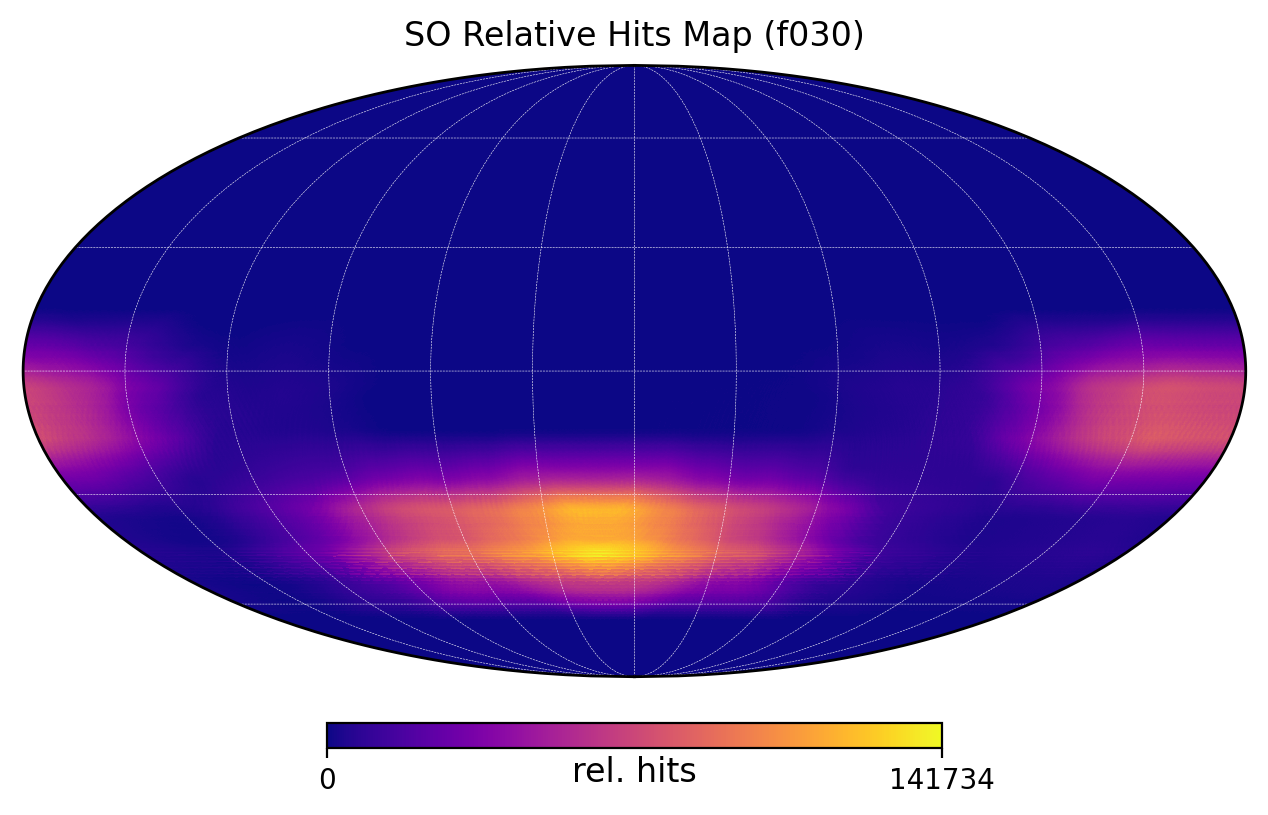

In [8]:
so_lf_hits = hp.read_map('/global/cfs/cdirs/sobs/sims/deso/unscaled/sat_wide/SAT_f030/sat_wide_SAT_f030_hits.fits')

fig = plt.figure(dpi=200)
hp.mollview(so_lf_hits, title='SO Relative Hits Map (f030)', unit='rel. hits', cmap='plasma', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

so_lf_bin  = np.zeros(so_lf_hits.shape)
so_lf_bin[so_lf_hits>min(so_lf_hits[so_lf_hits>0])] = 1.
so_lf_bin = st.mask_udgrade(so_lf_bin, 512)

so_lf_hits = st.change_resolution(so_lf_hits, fwhm_out=20., nside_out=512) * so_lf_bin

In [9]:
so_lf_hits[so_lf_hits < 0.] = 0.
so_lf_relhits = so_lf_hits / np.max(so_lf_hits)

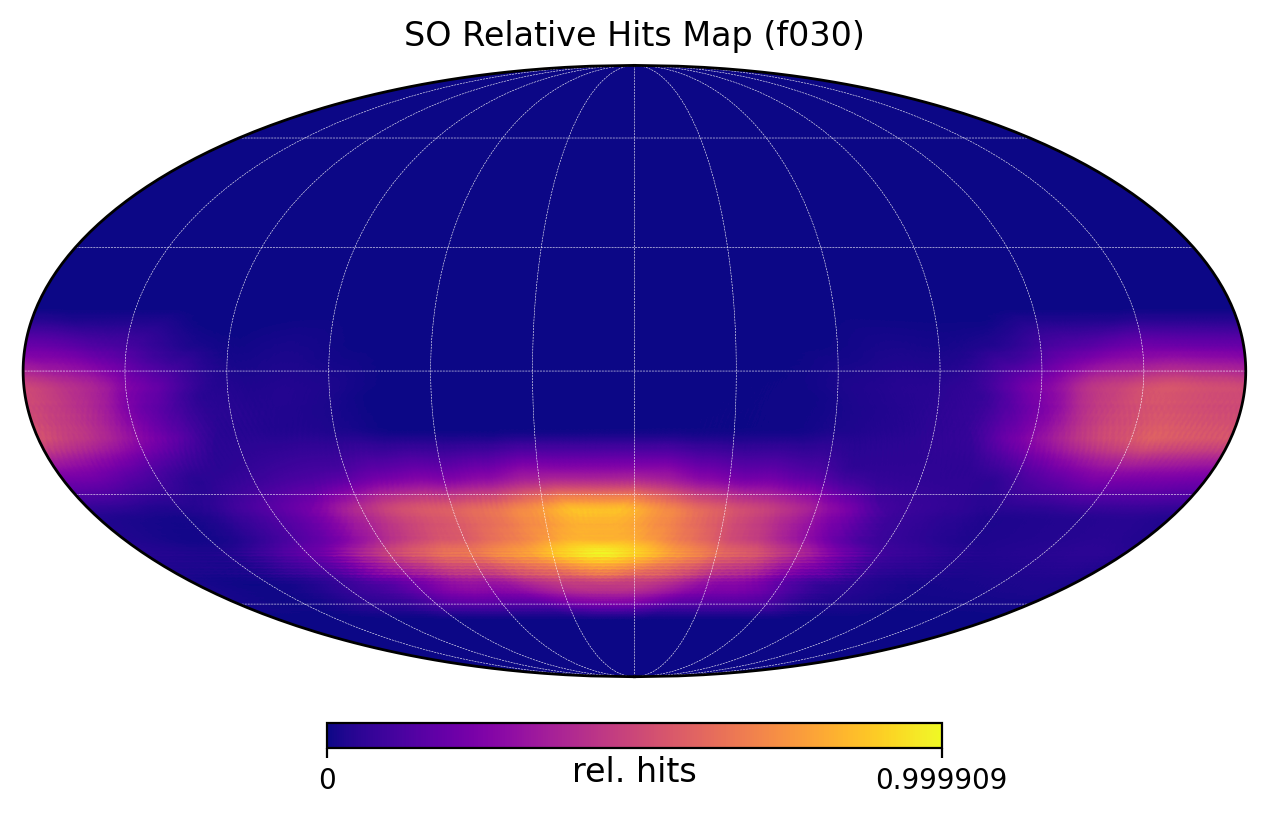

In [10]:
fig = plt.figure(dpi=200)
hp.mollview(so_lf_relhits, title='SO Relative Hits Map (f030)', unit='rel. hits', cmap='plasma', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [11]:
so_mf_hits = hp.read_map('/global/cfs/cdirs/sobs/sims/deso/unscaled/sat_wide/SAT_f090/sat_wide_SAT_f090_hits.fits')
so_mf_bin  = np.zeros(so_mf_hits.shape)
so_mf_bin[so_mf_hits>min(so_mf_hits[so_mf_hits>0])] = 1.
so_mf_bin = st.mask_udgrade(so_mf_bin, 512)

so_mf_hits = st.change_resolution(so_mf_hits, fwhm_out=20., nside_out=512) * so_mf_bin

In [12]:
so_mf_hits[so_mf_hits < 0.] = 0.
so_mf_relhits = so_mf_hits / np.max(so_mf_hits)

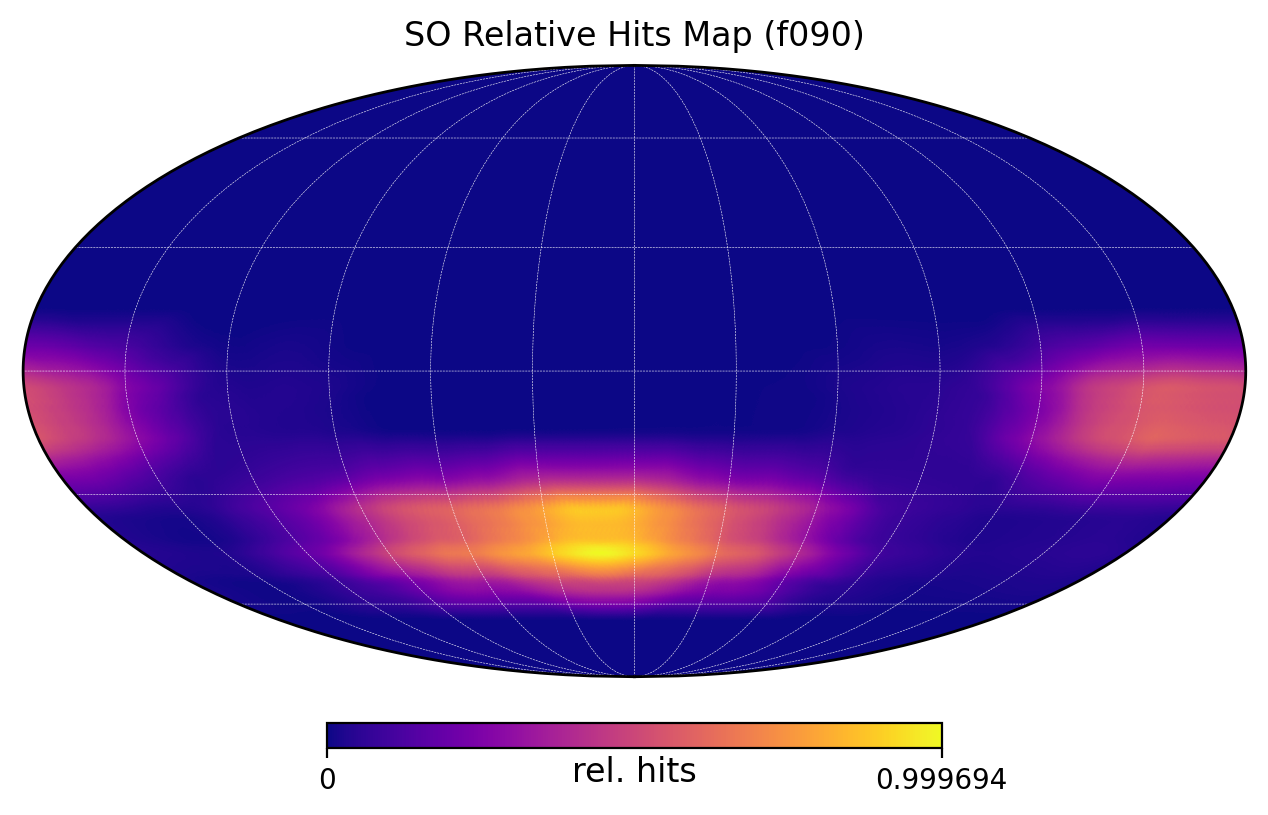

In [13]:
fig = plt.figure(dpi=200)
hp.mollview(so_mf_relhits, title='SO Relative Hits Map (f090)', unit='rel. hits', cmap='plasma', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [14]:
so_lf_bin = np.zeros_like(so_lf_bin)
so_lf_bin[so_lf_relhits > 0.] = 1. 

so_mf_bin = np.zeros_like(so_mf_bin)
so_mf_bin[so_mf_relhits > 0.] = 1. 

In [15]:
so_uhf_hits = hp.read_map('/global/cfs/cdirs/sobs/sims/deso/unscaled/sat_wide/SAT_f230/sat_wide_SAT_f230_hits.fits')
so_uhf_bin  = np.zeros(so_uhf_hits.shape)
so_uhf_bin[so_uhf_hits>min(so_uhf_hits[so_uhf_hits>0])] = 1.
so_uhf_bin = st.mask_udgrade(so_uhf_bin, 512)

so_uhf_hits = st.change_resolution(so_uhf_hits, fwhm_out=20., nside_out=512) * so_uhf_bin

In [16]:
so_uhf_hits[so_uhf_hits < 0.] = 0.
so_uhf_relhits = so_uhf_hits / np.max(so_uhf_hits)

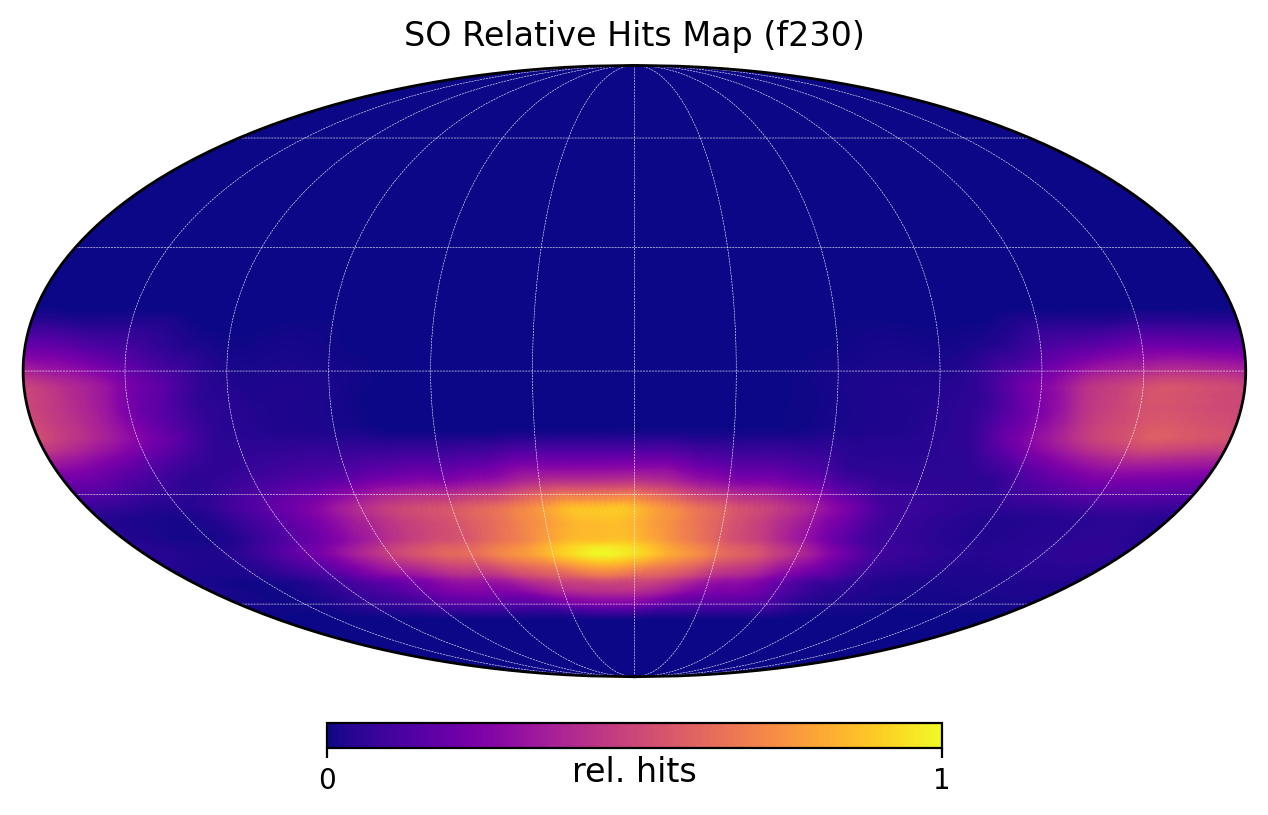

In [17]:
fig = plt.figure(dpi=200)
hp.mollview(so_uhf_relhits, title='SO Relative Hits Map (f230)', unit='rel. hits', cmap='plasma', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [18]:
so_uhf_bin = np.zeros_like(so_uhf_bin)
so_uhf_bin[so_uhf_relhits > 0.] = 1. 

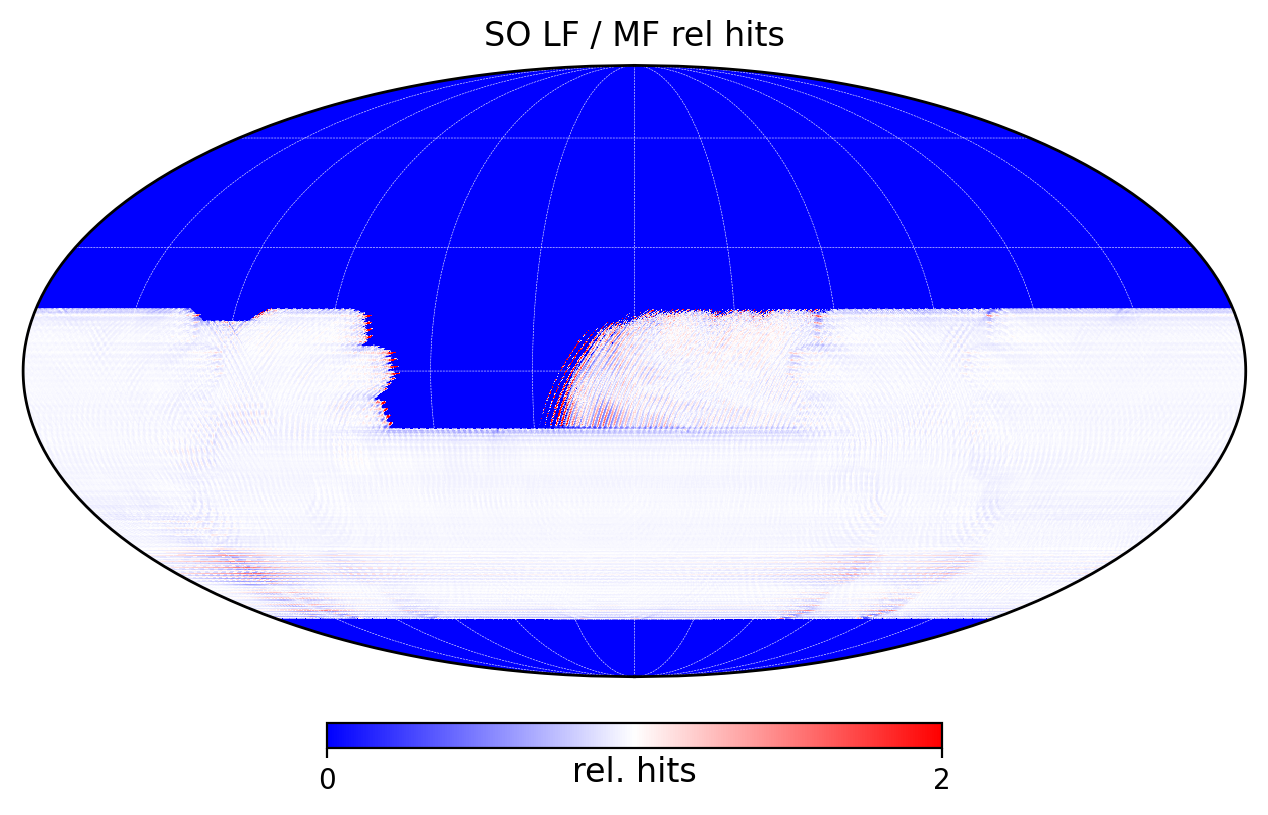

In [19]:
relhits_ratio = np.zeros_like(so_lf_relhits)
relhits_ratio[(so_lf_relhits > 0.) & (so_mf_relhits > 0.)] = so_lf_relhits[(so_lf_relhits > 0.) & (so_mf_relhits > 0.)] / so_mf_relhits[(so_lf_relhits > 0.) & (so_mf_relhits > 0.)]
fig = plt.figure(dpi=200)
hp.mollview(relhits_ratio, title='SO LF / MF rel hits', unit='rel. hits', cmap='bwr', xsize=1200, fig=fig.number, min=0., max=2.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

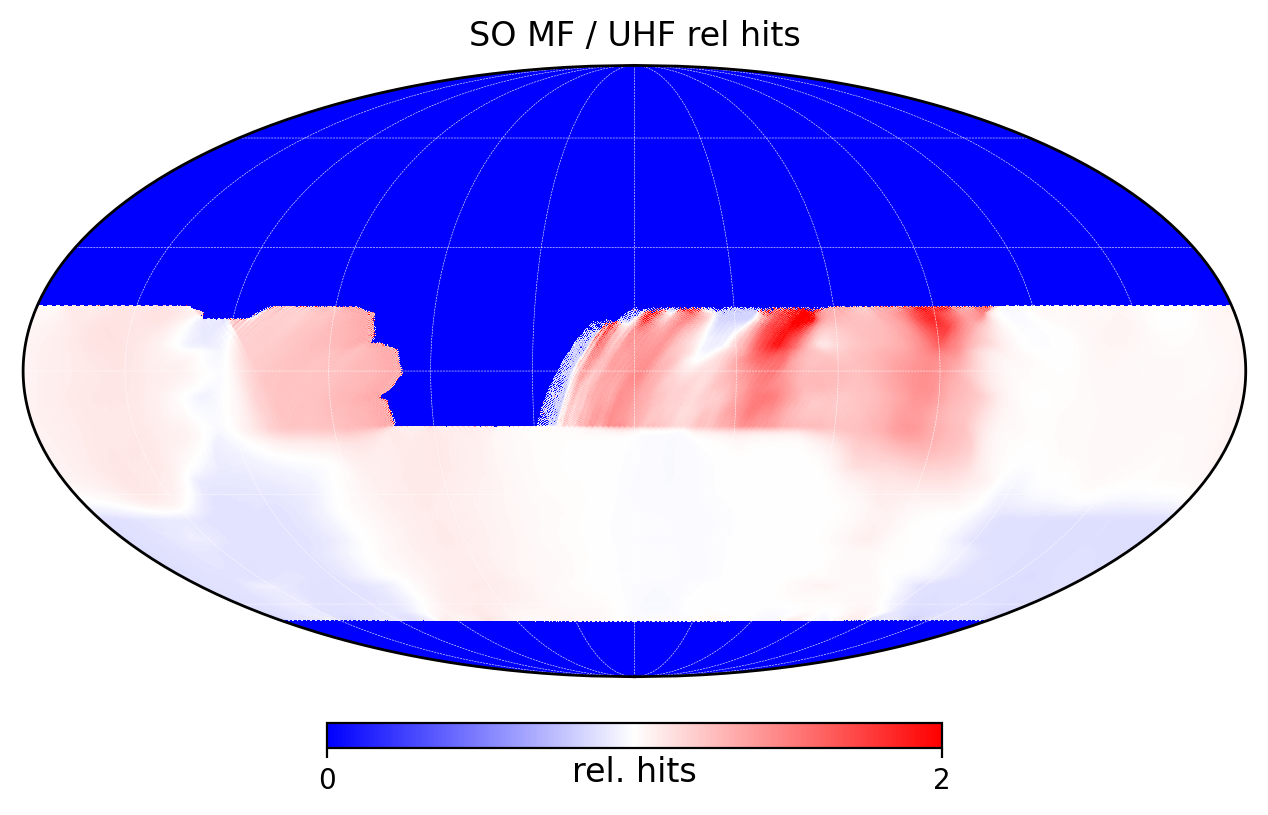

In [20]:
relhits_ratio = np.zeros_like(so_mf_relhits)
relhits_ratio[(so_mf_relhits > 0.) & (so_uhf_relhits > 0.)] = so_mf_relhits[(so_mf_relhits > 0.) & (so_uhf_relhits > 0.)] / so_uhf_relhits[(so_mf_relhits > 0.) & (so_uhf_relhits > 0.)]
fig = plt.figure(dpi=200)
hp.mollview(relhits_ratio, title='SO MF / UHF rel hits', unit='rel. hits', cmap='bwr', xsize=1200, fig=fig.number, min=0., max=2.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

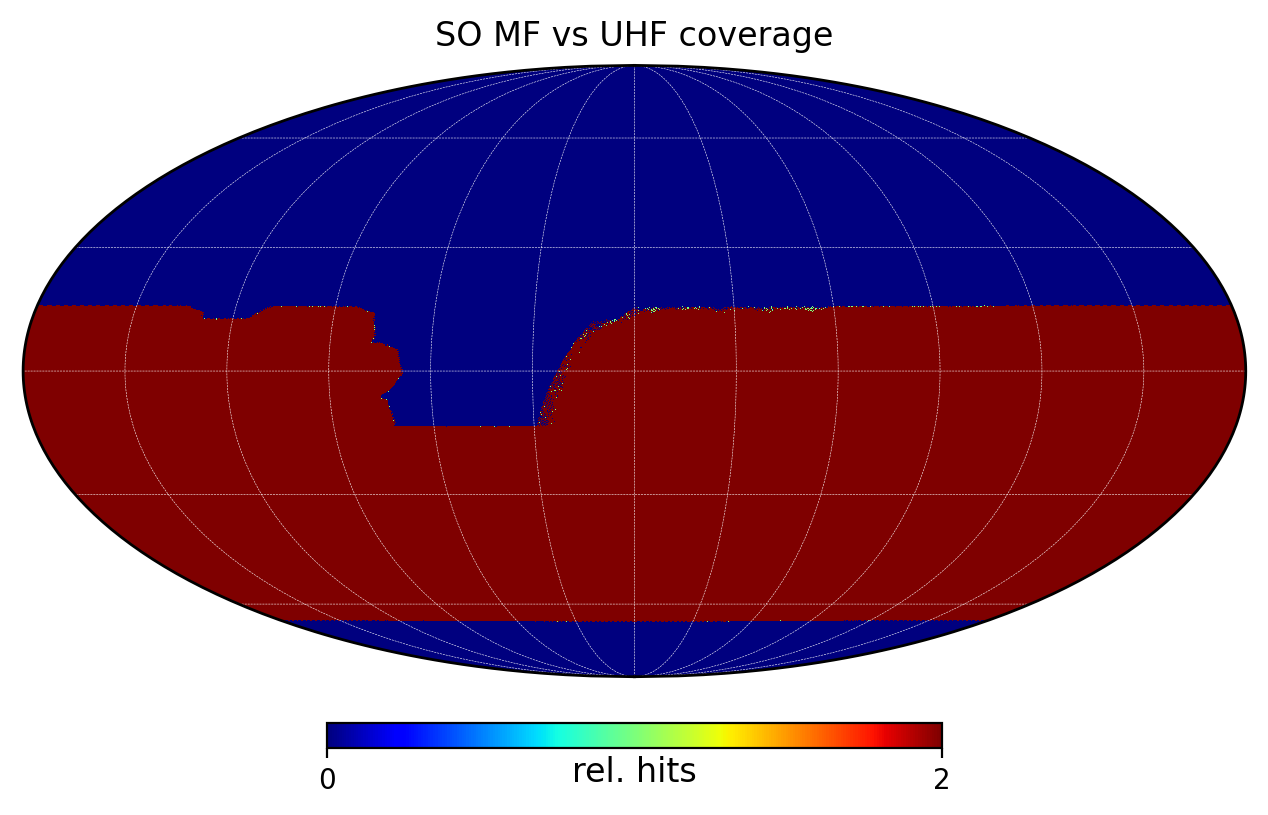

In [21]:
fig = plt.figure(dpi=200)
hp.mollview(so_mf_bin + so_uhf_bin, title='SO MF vs UHF coverage', unit='rel. hits', cmap='jet', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

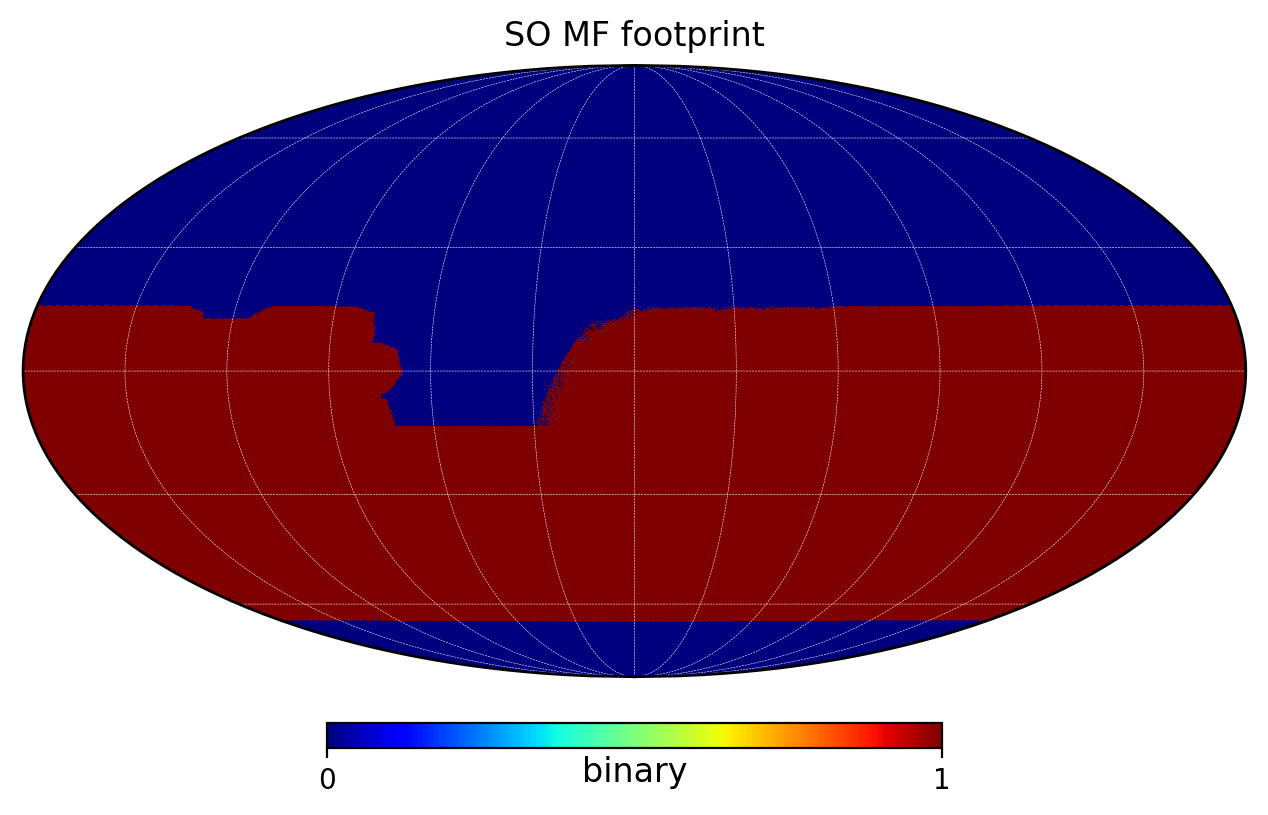

In [22]:
fig = plt.figure(dpi=200)
hp.mollview(so_mf_bin, title='SO MF footprint', unit='binary', cmap='jet', xsize=1200, fig=fig.number)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [23]:

tobs_tot_in_s_2mf = telescope_years_2MF * 365.25 * 24 * 60 * 60

tobs_per_pix_2mf = tobs_tot_in_s_2mf[2] * so_mf_relhits / np.sum(so_mf_relhits)
print("t_obs per pixel MF (2MF)", np.mean(tobs_per_pix_2mf[so_mf_relhits > 0.]), "s")

tobs_tot_in_s = telescope_years * 365.25 * 24 * 60 * 60

tobs_per_pix_lf = tobs_tot_in_s[0] * so_mf_relhits / np.sum(so_mf_relhits)
print("t_obs per pixel LF", np.mean(tobs_per_pix_lf[so_mf_relhits > 0.]), "s")

tobs_per_pix_mf = tobs_tot_in_s[2] * so_mf_relhits / np.sum(so_mf_relhits)
print("t_obs per pixel MF", np.mean(tobs_per_pix_mf[so_mf_relhits > 0.]), "s")

tobs_per_pix_hf = tobs_tot_in_s[4] * so_uhf_relhits / np.sum(so_uhf_relhits)
print("t_obs per pixel HF", np.mean(tobs_per_pix_hf[so_uhf_relhits > 0.]), "s")

tobs_per_pix_ehf = tobs_tot_in_s[6] * so_uhf_relhits / np.sum(so_uhf_relhits)
print("t_obs per pixel EHF", np.mean(tobs_per_pix_ehf[so_uhf_relhits > 0.]), "s")

tobs_tot_in_s_2hf = telescope_years_2HF * 365.25 * 24 * 60 * 60

tobs_per_pix_2hf = tobs_tot_in_s_2hf[4] * so_uhf_relhits / np.sum(so_uhf_relhits)
print("t_obs per pixel HF (2UHF)", np.mean(tobs_per_pix_2hf[so_uhf_relhits > 0.]), "s")

tobs_per_pix_2ehf = tobs_tot_in_s_2hf[6] * so_uhf_relhits / np.sum(so_uhf_relhits)
print("t_obs per pixel EHF (2EHF)", np.mean(tobs_per_pix_2ehf[so_uhf_relhits > 0.]), "s")

tobs_tot_in_s_keeplf = telescope_years_keepLF * 365.25 * 24 * 60 * 60

tobs_per_pix_lf_keep = tobs_tot_in_s_keeplf[0] * so_mf_relhits / np.sum(so_mf_relhits)
print("t_obs per pixel LF (keep LF)", np.mean(tobs_per_pix_lf_keep[so_mf_relhits > 0.]), "s")

t_obs per pixel MF (2MF) 388.85570210226587 s
t_obs per pixel LF 36.46091909069535 s
t_obs per pixel MF 680.5430548278287 s
t_obs per pixel HF 182.36243186892946 s
t_obs per pixel EHF 127.65370230825064 s
t_obs per pixel HF (2UHF) 310.0161341771801 s
t_obs per pixel EHF (2EHF) 255.3074046165013 s
t_obs per pixel LF (keep LF) 154.95890613545524 s


In [24]:
def varpix2uKarcmin(var_map):
    nside_in = hp.get_nside(var_map)
    pixarea_deg = hp.nside2pixarea(nside_in, degrees=True)

    return 60. * np.sqrt(var_map * pixarea_deg) 

The $\sqrt2$ factor is included to convert from NET to NEQ/U

Note: `detector_yield` is already included for all channels other than 346 GHz 

In [25]:
so_f093_noise_var = np.zeros_like(so_mf_relhits)
so_f093_noise_var[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[2])**2. / (tobs_per_pix_mf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f145_noise_var = np.zeros_like(so_mf_relhits)
so_f145_noise_var[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[3])**2. / (tobs_per_pix_mf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [33]:
so_f138_noise_var = np.zeros_like(so_mf_relhits)
so_f138_noise_var[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope_split[0])**2. / (tobs_per_pix_mf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f152_noise_var = np.zeros_like(so_mf_relhits)
so_f152_noise_var[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope_split[1])**2. / (tobs_per_pix_mf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [26]:
so_f093_noise_var_2MF = np.zeros_like(so_mf_relhits)
so_f093_noise_var_2MF[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[2])**2. / (tobs_per_pix_2mf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f145_noise_var_2MF = np.zeros_like(so_mf_relhits)
so_f145_noise_var_2MF[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[3])**2. / (tobs_per_pix_2mf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [28]:
so_f027_noise_var = np.zeros_like(so_mf_relhits)
so_f027_noise_var[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[0])**2. / (tobs_per_pix_lf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f039_noise_var = np.zeros_like(so_mf_relhits)
so_f039_noise_var[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[1])**2. / (tobs_per_pix_lf[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [29]:
so_f027_noise_var_keep = np.zeros_like(so_mf_relhits)
so_f027_noise_var_keep[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[0])**2. / (tobs_per_pix_lf_keep[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f039_noise_var_keep = np.zeros_like(so_mf_relhits)
so_f039_noise_var_keep[so_mf_relhits > 0.] = (np.sqrt(2) * NET_telescope[1])**2. / (tobs_per_pix_lf_keep[so_mf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [30]:
so_f225_noise_var = np.zeros_like(so_uhf_relhits)
so_f225_noise_var[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope[4])**2. / (tobs_per_pix_hf[so_uhf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f280_noise_var = np.zeros_like(so_uhf_relhits)
so_f280_noise_var[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope[5])**2. / (tobs_per_pix_hf[so_uhf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)


In [31]:
so_f214_noise_var = np.zeros_like(so_uhf_relhits)
so_f214_noise_var[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope_split[2])**2. / (tobs_per_pix_hf[so_uhf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f236_noise_var = np.zeros_like(so_uhf_relhits)
so_f236_noise_var[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope_split[3])**2. / (tobs_per_pix_hf[so_uhf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [35]:
so_f225_noise_var_2HF = np.zeros_like(so_uhf_relhits)
so_f225_noise_var_2HF[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope[4])**2. / (tobs_per_pix_2hf[so_uhf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

so_f280_noise_var_2HF = np.zeros_like(so_uhf_relhits)
so_f280_noise_var_2HF[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope[5])**2. / (tobs_per_pix_2hf[so_uhf_relhits > 0.] * nonpwv_obs_eff)# * modeloss_penalty)

In [36]:
so_f346_noise_var = np.zeros_like(so_uhf_relhits)
so_f346_noise_var[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope[6])**2. / (tobs_per_pix_ehf[so_uhf_relhits > 0.] * detector_yield * nonpwv_obs_eff)# * modeloss_penalty)

so_f346_noise_var_2EHF = np.zeros_like(so_uhf_relhits)
so_f346_noise_var_2EHF[so_uhf_relhits > 0.] = (np.sqrt(2) * NET_telescope[6])**2. / (tobs_per_pix_2ehf[so_uhf_relhits > 0.] * detector_yield * nonpwv_obs_eff)# * modeloss_penalty)

In [37]:
print("uK-arcmin (f027) :", np.mean(varpix2uKarcmin(so_f027_noise_var)[so_mf_relhits == 1.]))
print("uK-arcmin (f027) keep LF :", np.mean(varpix2uKarcmin(so_f027_noise_var_keep)[so_mf_relhits == 1.]))
print("uK-arcmin (f039) :", np.mean(varpix2uKarcmin(so_f039_noise_var)[so_mf_relhits == 1.]))
print("uK-arcmin (f039) keep LF :", np.mean(varpix2uKarcmin(so_f039_noise_var_keep)[so_mf_relhits == 1.]))
print("uK-arcmin (f093) :", np.mean(varpix2uKarcmin(so_f093_noise_var)[so_mf_relhits == 1]))
print("uK-arcmin (f093) 2MF :", np.mean(varpix2uKarcmin(so_f093_noise_var_2MF)[so_mf_relhits == 1]))
print("uK-arcmin (f138) :", np.mean(varpix2uKarcmin(so_f138_noise_var)[so_mf_relhits == 1]))
print("uK-arcmin (f145) :", np.mean(varpix2uKarcmin(so_f145_noise_var)[so_mf_relhits == 1]))
print("uK-arcmin (f145) 2MF :", np.mean(varpix2uKarcmin(so_f145_noise_var_2MF)[so_mf_relhits == 1]))
print("uK-arcmin (f152) :", np.mean(varpix2uKarcmin(so_f152_noise_var)[so_mf_relhits == 1]))
print("uK-arcmin (f214) :", np.mean(varpix2uKarcmin(so_f214_noise_var)[so_uhf_relhits == 1]))
print("uK-arcmin (f225) :", np.mean(varpix2uKarcmin(so_f225_noise_var)[so_uhf_relhits == 1]))
print("uK-arcmin (f236) :", np.mean(varpix2uKarcmin(so_f236_noise_var)[so_uhf_relhits == 1]))
print("uK-arcmin (f280) :", np.mean(varpix2uKarcmin(so_f280_noise_var)[so_uhf_relhits == 1]))
print("uK-arcmin (f225) 2UHF:", np.mean(varpix2uKarcmin(so_f225_noise_var_2HF)[so_uhf_relhits == 1]))
print("uK-arcmin (f280) 2UHF:", np.mean(varpix2uKarcmin(so_f280_noise_var_2HF)[so_uhf_relhits == 1]))
print("uK-arcmin (f346) :", np.mean(varpix2uKarcmin(so_f346_noise_var)[so_uhf_relhits == 1]))
print("uK-arcmin (f346) 2EHF:", np.mean(varpix2uKarcmin(so_f346_noise_var_2EHF)[so_uhf_relhits == 1]))

uK-arcmin (f027) : 25.313462659719466
uK-arcmin (f027) keep LF : 12.278832976017872
uK-arcmin (f039) : 15.670238789350146
uK-arcmin (f039) keep LF : 7.601182318487255
uK-arcmin (f093) : 0.948630714646473
uK-arcmin (f093) 2MF : 1.2549625017853938
uK-arcmin (f138) : 1.9530632360368563
uK-arcmin (f145) : 1.3950451685977543
uK-arcmin (f145) 2MF : 1.8455330908608734
uK-arcmin (f152) : 1.9530632360368563
uK-arcmin (f214) : 6.399491203967192
uK-arcmin (f225) : 4.586302029509821
uK-arcmin (f236) : 6.399491203967192
uK-arcmin (f280) : 11.732400540606518
uK-arcmin (f225) 2UHF: 3.5175330849136723
uK-arcmin (f280) 2UHF: 8.998340449779162
uK-arcmin (f346) : 38.092209547423764
uK-arcmin (f346) 2EHF: 26.93525968136229


In [38]:
hp.write_map(f'../resources/variance_maps/so_f027_noise_var_{telescope_years[0]:.2f}tel-yrs.fits', so_f027_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f027_noise_var_{telescope_years_keepLF[0]:.2f}tel-yrs.fits', so_f027_noise_var_keep, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f039_noise_var_{telescope_years[1]:.2f}tel-yrs.fits', so_f039_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f039_noise_var_{telescope_years_keepLF[1]:.2f}tel-yrs.fits', so_f039_noise_var_keep, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f093_noise_var_{telescope_years[2]:.2f}tel-yrs.fits', so_f093_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f093_noise_var_{telescope_years_2MF[2]:.2f}tel-yrs.fits', so_f093_noise_var_2MF, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f138_noise_var_{telescope_years[3]:.2f}tel-yrs.fits', so_f138_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f145_noise_var_{telescope_years[3]:.2f}tel-yrs.fits', so_f145_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f152_noise_var_{telescope_years[3]:.2f}tel-yrs.fits', so_f152_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f145_noise_var_{telescope_years_2MF[3]:.2f}tel-yrs.fits', so_f145_noise_var_2MF, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f214_noise_var_{telescope_years[4]:.2f}tel-yrs.fits', so_f214_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f225_noise_var_{telescope_years[4]:.2f}tel-yrs.fits', so_f225_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f236_noise_var_{telescope_years[4]:.2f}tel-yrs.fits', so_f236_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f225_noise_var_{telescope_years_2HF[4]:.2f}tel-yrs.fits', so_f225_noise_var_2HF, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f280_noise_var_{telescope_years[5]:.2f}tel-yrs.fits', so_f280_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f280_noise_var_{telescope_years_2HF[5]:.2f}tel-yrs.fits', so_f280_noise_var_2HF, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f346_noise_var_{telescope_years[6]:.2f}tel-yrs.fits', so_f346_noise_var, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)
hp.write_map(f'../resources/variance_maps/so_f346_noise_var_{telescope_years_2HF[6]:.2f}tel-yrs.fits', so_f346_noise_var_2EHF, overwrite=True, column_names=['pol noise var pix'], column_units=['uK_CMB^2'],)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


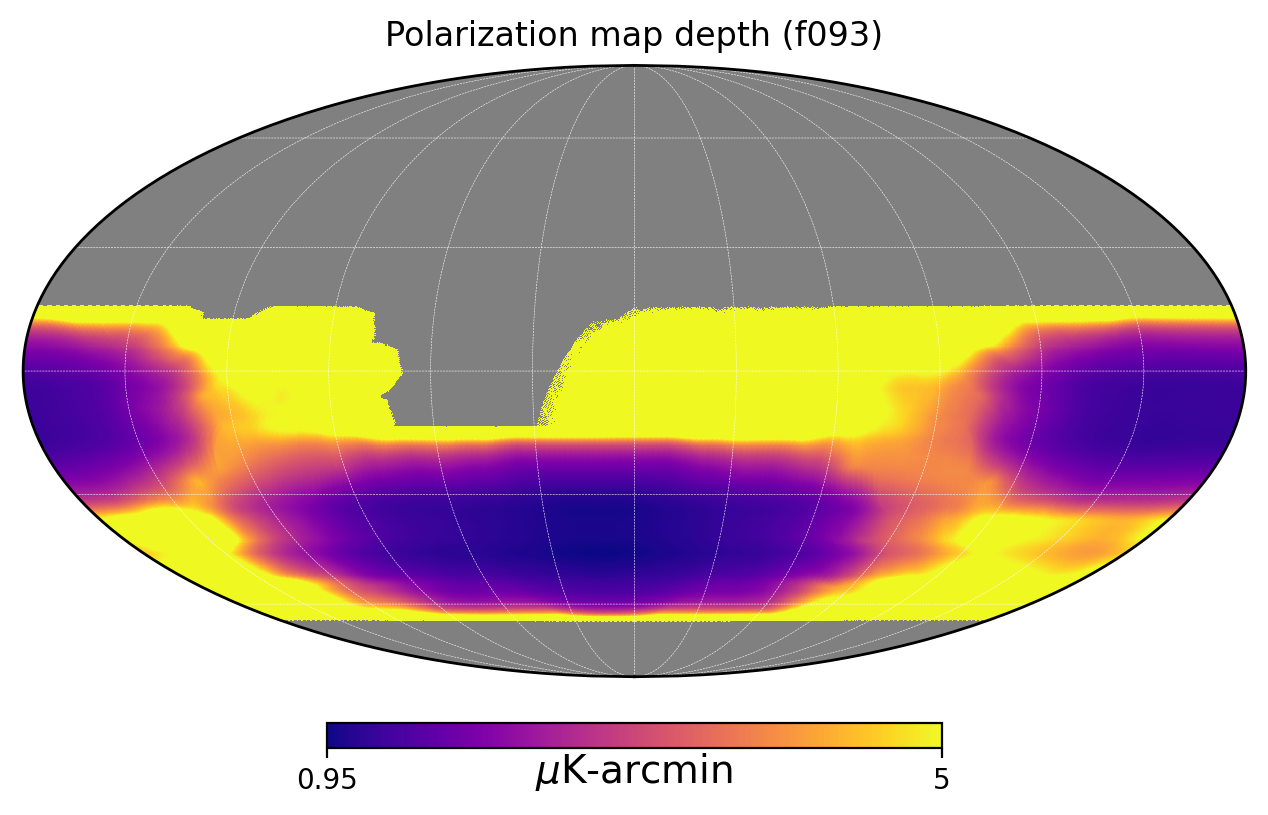

In [33]:
fig = plt.figure(dpi=200)
hp.mollview(varpix2uKarcmin(so_f093_noise_var) + (1 - so_mf_bin) * hp.UNSEEN, title='Polarization map depth (f093)', unit=r'$\mu$K-arcmin', cmap='plasma', xsize=1200, fig=fig.number, min=0.95, max=5.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

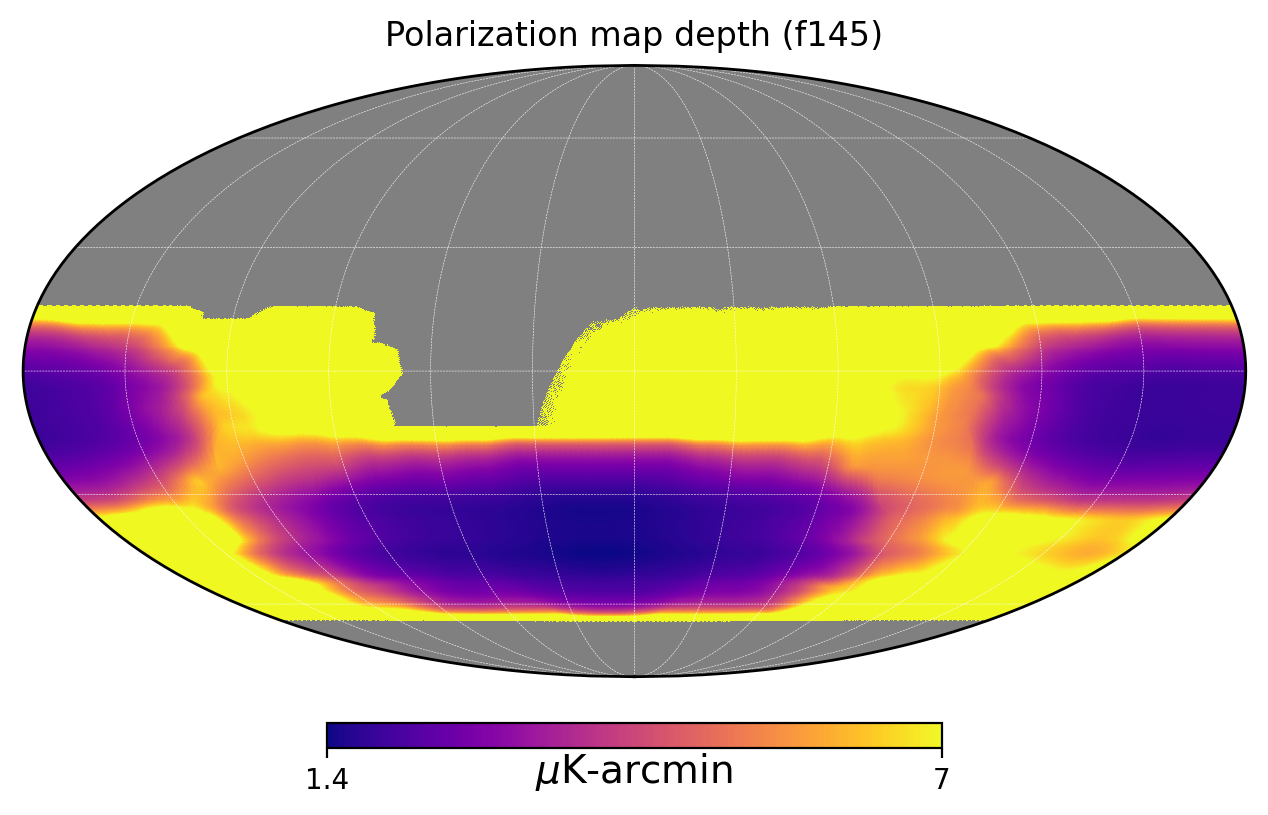

In [34]:
fig = plt.figure(dpi=200)
hp.mollview(varpix2uKarcmin(so_f145_noise_var) + (1 - so_mf_bin) * hp.UNSEEN, title='Polarization map depth (f145)', unit=r'$\mu$K-arcmin', cmap='plasma', xsize=1200, fig=fig.number, min=1.4, max=7.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

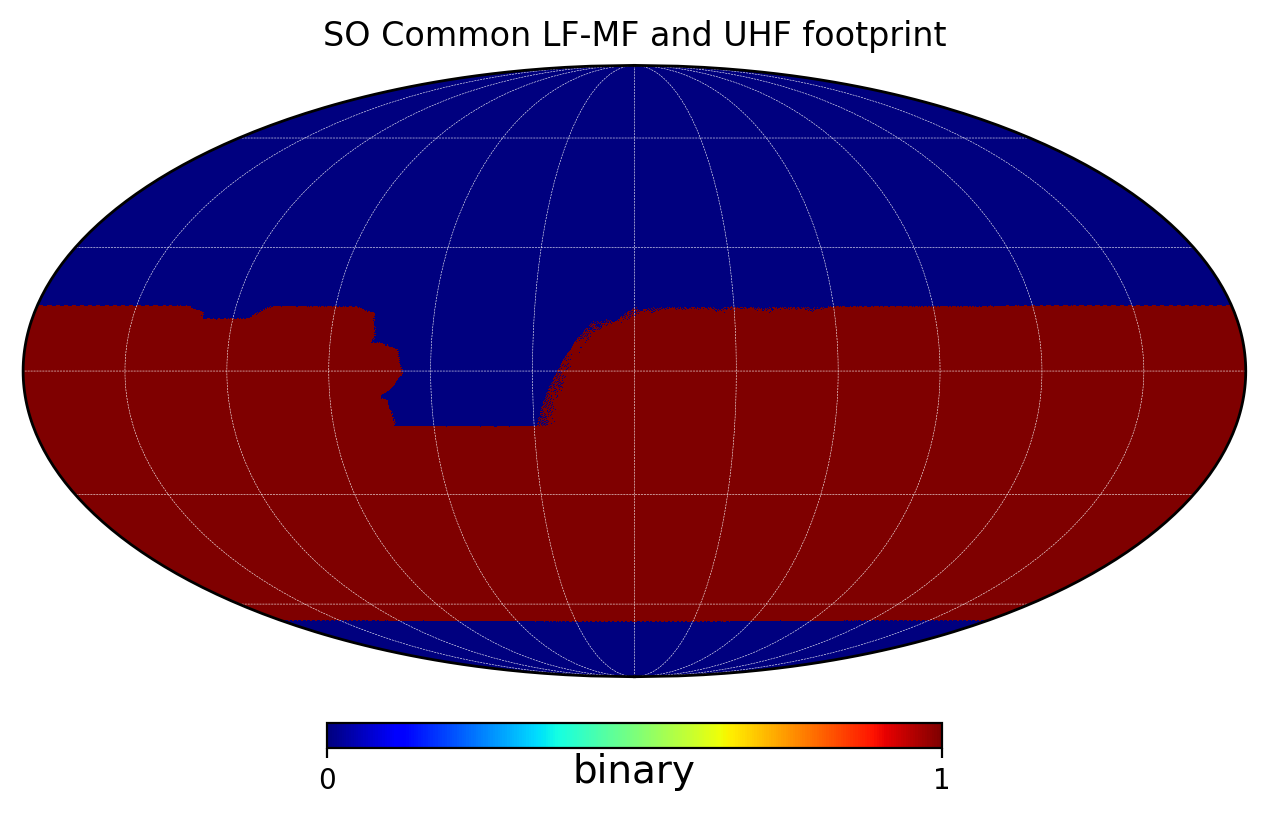

In [35]:
so_common = so_mf_bin + so_uhf_bin
so_common[so_common < 2.] = 0.
so_common[so_common >= 2.] = 1.

fig = plt.figure(dpi=200)
hp.mollview(so_common, title='SO Common LF-MF and UHF footprint', unit='binary', cmap='jet', xsize=1200, fig=fig.number)    
hp.graticule(30, 30, lw=0.2, ls='--', c='w') 

In [36]:
hp.write_map('../resources/so_lf_mf_relhits_512.fits', so_mf_relhits, overwrite=True)
hp.write_map('../resources/so_uhf_relhits_512.fits', so_uhf_relhits, overwrite=True)
hp.write_map('../resources/so_lfmf_bin_512.fits', so_mf_bin, overwrite=True)
hp.write_map('../resources/so_uhf_bin_512.fits', so_uhf_bin, overwrite=True)
hp.write_map('../resources/so_common_lf_mf_uhf_bin_512.fits', so_common, overwrite=True)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


In [37]:
gal_mask = st.latitude_mask(512, 7.,)
rot = hp.Rotator(coord=('G', 'C'))
gal_mask = rot.rotate_map_pixel(gal_mask)
gal_mask[gal_mask > 0.5] = 1.
gal_mask[gal_mask <= 0.5] = 0.

In [38]:
mapdepth_f93 = varpix2uKarcmin(so_f093_noise_var)
ra, dec = hp.pix2ang(512, np.arange(hp.nside2npix(512)), lonlat=True)
l, b = hp.pix2ang(512, np.arange(hp.nside2npix(512)), lonlat=True)

south_gal_mask = np.zeros(mapdepth_f93.shape)
south_gal_mask[b < -10.] = 1.

rot = hp.Rotator(coord=('G', 'C'))
south_gal_mask = rot.rotate_map_pixel(south_gal_mask)
south_gal_mask[south_gal_mask > 0.5] = 1.
south_gal_mask[south_gal_mask <= 0.5] = 0.

dec_cut_mask = np.zeros(mapdepth_f93.shape)
dec_cut_mask[(dec < -15) & (dec > -65)] = 1.

south_patch_mask = south_gal_mask * dec_cut_mask 
south_patch_mask[mapdepth_f93 > 4.5] = 0.


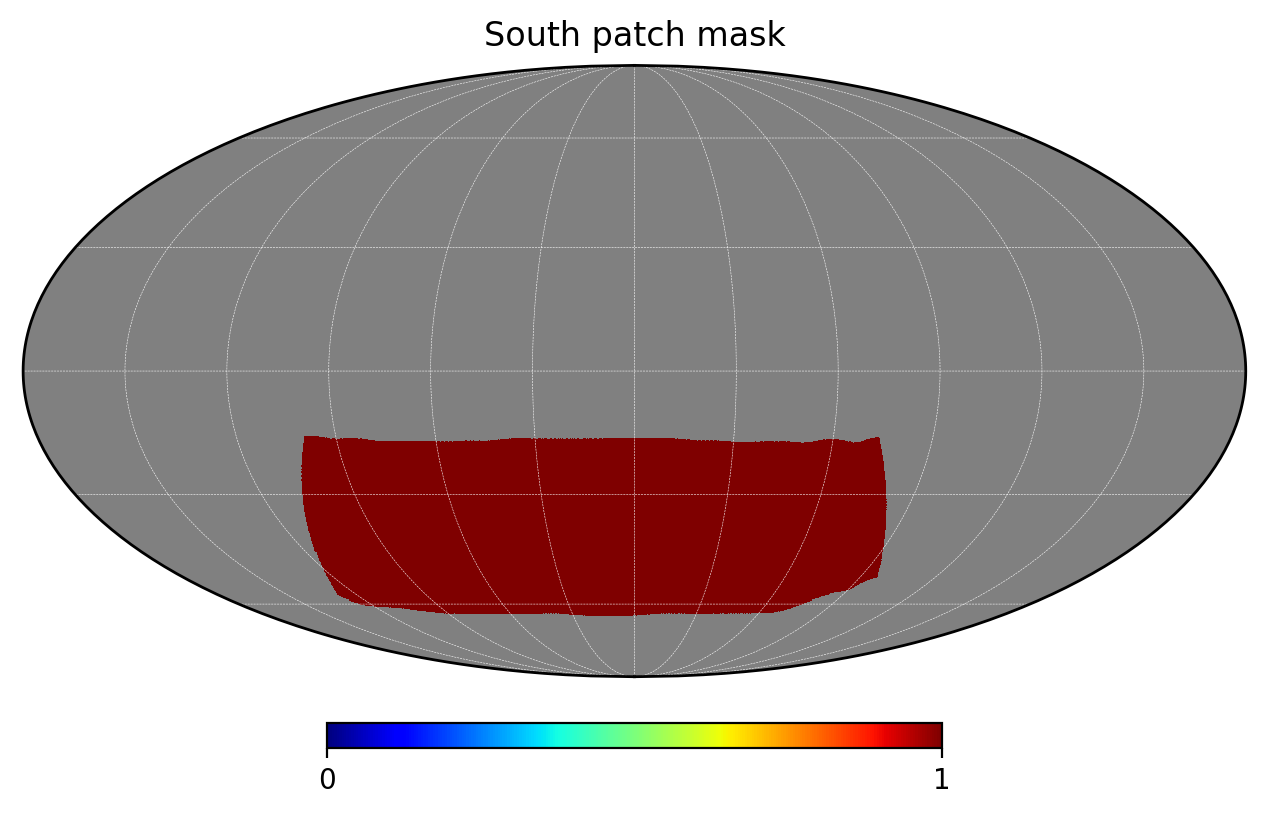

In [39]:
fig = plt.figure(dpi=200)
hp.mollview(south_patch_mask + (1 - south_patch_mask) * hp.UNSEEN, title='South patch mask', unit=None, cmap='jet', xsize=1200, fig=fig.number, min=0, max=1.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [40]:
south_patch_2dC2 = nmt.mask_apodization(south_patch_mask, 2., apotype='C2')

rel_hits_south = so_lf_mf_relhits * south_patch_2dC2

rel_hits_south /= np.max(rel_hits_south)

fig = plt.figure(dpi=200)
hp.mollview(rel_hits_south + (1 - south_patch_mask) * hp.UNSEEN, title=f'South patch rel. hits mask (fsky={st.fsky(rel_hits_south):.2f}, fsky signal={st.fsky_signal(rel_hits_south):.2f}, fsky noise={st.fsky_noise(rel_hits_south):.2f})', unit='Rel. hits', cmap='plasma', xsize=1200, fig=fig.number, min=0, max=1.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

NameError: name 'so_lf_mf_relhits' is not defined

In [ ]:
hp.write_map(f'../resources/so_south_patch_binary.fits', south_patch_mask, overwrite=True)
hp.write_map(f'../resources/so_south_patch_2dC2.fits', south_patch_2dC2, overwrite=True)
hp.write_map(f'../resources/so_south_relhits_2dC2.fits', rel_hits_south, overwrite=True)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]


In [ ]:
north_gal_mask = np.zeros(mapdepth_f93.shape)
north_gal_mask[b > 11.] = 1.

rot = hp.Rotator(coord=('G', 'C'))
north_gal_mask = rot.rotate_map_pixel(north_gal_mask)
north_gal_mask[north_gal_mask > 0.5] = 1.
north_gal_mask[north_gal_mask <= 0.5] = 0.

dec_cut_mask = np.zeros(mapdepth_f93.shape)
dec_cut_mask[(dec > -45) & (dec < 10)] = 1.

north_patch_mask = north_gal_mask * dec_cut_mask 
north_patch_mask[mapdepth_f93 > 4.5] = 0.


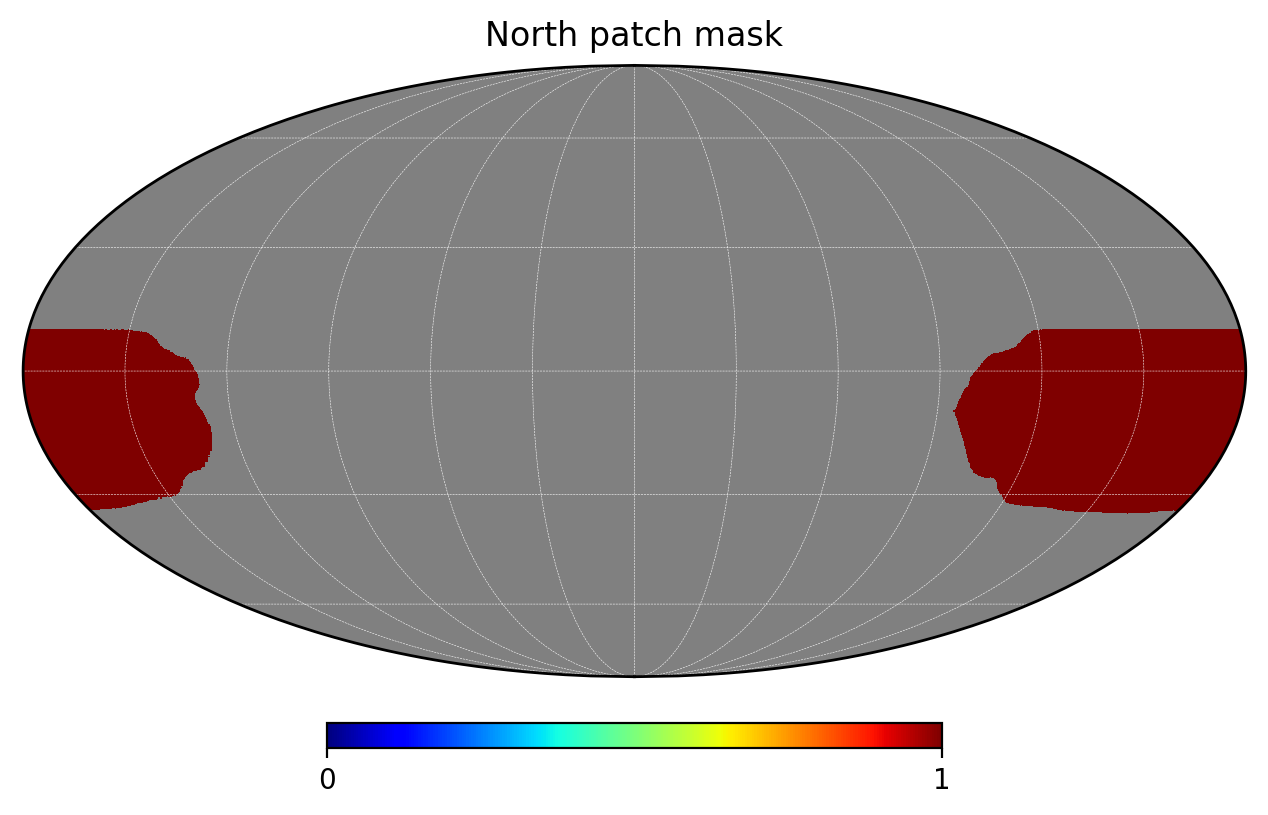

In [ ]:
fig = plt.figure(dpi=200)
hp.mollview(north_patch_mask + (1 - north_patch_mask) * hp.UNSEEN, title='North patch mask', unit=None, cmap='jet', xsize=1200, fig=fig.number, min=0, max=1.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

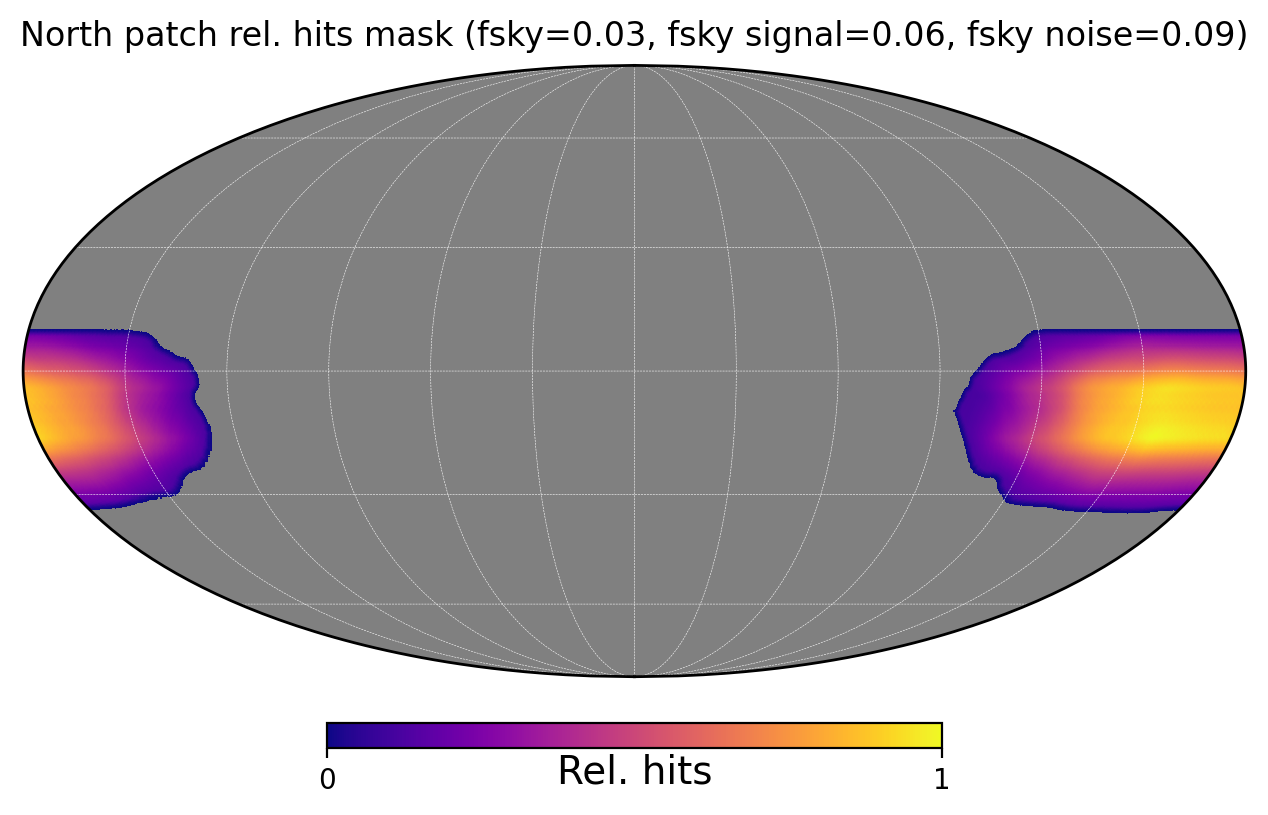

In [ ]:
north_patch_2dC2 = nmt.mask_apodization(north_patch_mask, 2., apotype='C2')

rel_hits_north = so_lf_mf_relhits * north_patch_2dC2

rel_hits_north /= np.max(rel_hits_north)

fig = plt.figure(dpi=200)
hp.mollview(rel_hits_north + (1 - north_patch_mask) * hp.UNSEEN, title=f'North patch rel. hits mask (fsky={st.fsky(rel_hits_north):.2f}, fsky signal={st.fsky_signal(rel_hits_north):.2f}, fsky noise={st.fsky_noise(rel_hits_north):.2f})', unit='Rel. hits', cmap='plasma', xsize=1200, fig=fig.number, min=0, max=1.)
hp.graticule(30, 30, lw=0.2, ls='--', c='w')

In [ ]:
hp.write_map(f'../resources/so_north_patch_binary.fits', north_patch_mask, overwrite=True)
hp.write_map(f'../resources/so_north_patch_2dC2.fits', north_patch_2dC2, overwrite=True)
hp.write_map(f'../resources/so_north_relhits_2dC2.fits', rel_hits_north, overwrite=True)

setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
setting the output map dtype to [dtype('float64')]
